# Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

# **Task 1: Data Preparation**

**Loading the Data**

    • Download the provided folder that contains the Devnagari digits dataset.

    • Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

    • Convert the images into Numpy arrays and normalize them to a range of 0-1.

    • use train folder for training and test for testing.

    • Extract the corresponding labels for each image.

**Hints:**

    • Ensure that the images are resized to a consistent shape (e.g., 28x28).

    • Convert labels to one-hot encoded format for multi-class classification.

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import os

# Dataset path
dataset_path = "/content/drive/MyDrive/AI-Sem6/week4/DevanagariHandwrittenDigitDataset"

# Train and test folders
train_path = os.path.join(dataset_path, "Train")
test_path = os.path.join(dataset_path, "Test")

Loading the Dataset

In [39]:
import numpy as np
from PIL import Image

# Function to load images and labels
def load_data(folder_path):
    images = []
    labels = []

    # Read each class folder like digit_0, digit_1, ..., digit_9
    for class_name in sorted(os.listdir(folder_path)):
        class_folder = os.path.join(folder_path, class_name)

        # Skip if it is not a folder
        if os.path.isdir(class_folder):

            # Get label from folder name
            label = int(class_name.split("_")[-1])

            # Read each image inside the folder
            for file_name in os.listdir(class_folder):
                file_path = os.path.join(class_folder, file_name)

                # Open image in grayscale
                img = Image.open(file_path).convert("L")

                # Resize image to 28 x 28
                img = img.resize((28, 28))

                # Convert image to numpy array
                img = np.array(img)

                # Normalize image
                img = img / 255.0

                # Store image and label
                images.append(img)
                labels.append(label)

    # Convert lists to numpy arrays
    images = np.array(images)
    labels = np.array(labels)

    return images, labels

Read train and test data

In [40]:
# Load train and test data
x_train, y_train = load_data(train_path)
x_test, y_test = load_data(test_path)

# Print shapes
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (17028, 28, 28)
y_train shape: (17028,)
x_test shape: (3000, 28, 28)
y_test shape: (3000,)


Reshape and One-hot encode

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Reshape images for Keras input
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoded form
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Print new shapes
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (17028, 28, 28, 1)
x_test shape: (3000, 28, 28, 1)
y_train shape: (17028, 10)
y_test shape: (3000, 10)


In [42]:
# Shuffle training data before validation split
indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)

x_train = x_train[indices]
y_train = y_train[indices]

Display some training images

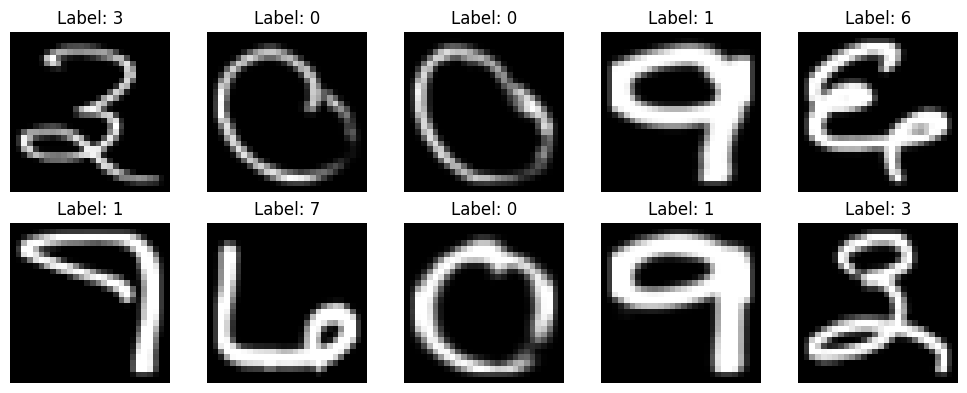

In [45]:
import matplotlib.pyplot as plt

# Show first 10 training images
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Label: " + str(np.argmax(y_train[i])))
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Task 2: Build the FCN Model**

**Model Architecture**

    • Create a Sequential model using Keras.

    • Add 3 hidden layers with the following number of neurons:
      – 1st hidden layer: 64 neurons
      – 2nd hidden layer: 128 neurons
      – 3rd hidden layer: 256 neurons

    • Use sigmoid activation functions for all hidden layers.

    • Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
    softmax activation function.

In [46]:
# Build the Sequential model
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation="sigmoid"),
    Dense(128, activation="sigmoid"),
    Dense(256, activation="sigmoid"),
    Dense(10, activation="softmax")
])

Model Summary

In [47]:
# Show model summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# **Task 3: Compile the Model**

**Model Compilation**

    • Choose an appropriate optimizer (e. g., Adam), loss function (e.g., sparse categorical crossentropy),
    and evaluation metric (e.g., accuracy).

In [48]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# **Task 4: Train the Model**

**Model Training**

    • Use the model.fit() function to train the model. Set the batch size to 128 and the number of epochs to 20.

    • Use validation split (validation split=0.2) to monitor the model’s performance on validation data.

    • Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoiding overfitting.

In [49]:
# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4852 - loss: 1.7940 - val_accuracy: 0.7786 - val_loss: 0.9490
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8278 - loss: 0.5895 - val_accuracy: 0.8488 - val_loss: 0.4419
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8902 - loss: 0.3424 - val_accuracy: 0.9096 - val_loss: 0.3189
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9318 - loss: 0.2442 - val_accuracy: 0.9234 - val_loss: 0.2477
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9488 - loss: 0.1833 - val_accuracy: 0.9363 - val_loss: 0.2021
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9625 - loss: 0.1421 - val_accuracy: 0.9472 - val_loss: 0.1777
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9705 - loss: 0.1139 - val_accuracy: 0.9548 - val_loss: 0.1479
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9757 - loss: 0.0946 - val_accuracy: 0.

Vizualize loss and accuracy

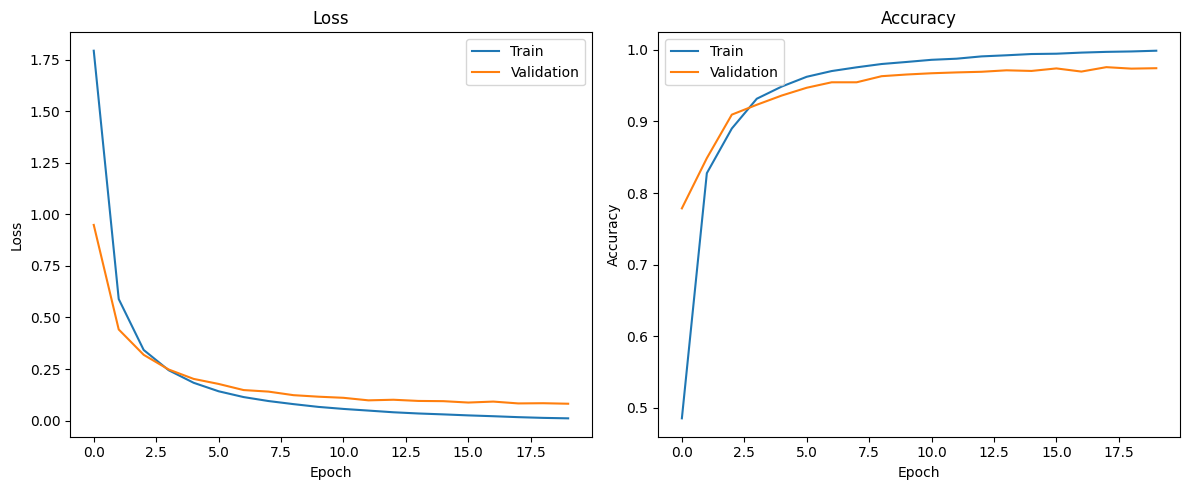

In [50]:
# Plot loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.tight_layout()
plt.show()

# **Task 5: Evaluate the Model**

**Model Evaluation**

    • After training, evaluate the model using model.evaluate() on the test set to check the test
    accuracy and loss.

In [51]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9800 - loss: 0.0818
Test Loss: 0.08183195441961288
Test Accuracy: 0.9800000190734863


# **Task 6: Save and Load the Model**
**Model Saving and Loading**

    • Save the trained model to an .h5 file using model.save().
    
    • Load the saved model and re-evaluate its performance on the test set.

In [52]:
# Save the model
model.save("devanagari_fcn_model.h5")

In [53]:
# Load the saved model
loaded_model = load_model("devanagari_fcn_model.h5")

In [54]:
# Evaluate loaded model
loss, accuracy = loaded_model.evaluate(x_test, y_test)

print("Loaded Model Test Loss:", loss)
print("Loaded Model Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.0818
Loaded Model Test Loss: 0.08183195441961288
Loaded Model Test Accuracy: 0.9800000190734863


# **Task 7: Predictions**
**Making Predictions**

    • Use model.predict() to make predictions on test images.
    
    • Convert the model’s predicted probabilities to digit labels using np.argmax().

In [55]:
# Make predictions
predictions = loaded_model.predict(x_test)

# Convert probabilities to labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("First 10 predicted labels:", predicted_labels[:10])
print("First 10 true labels:", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 true labels: [0 0 0 0 0 0 0 0 0 0]


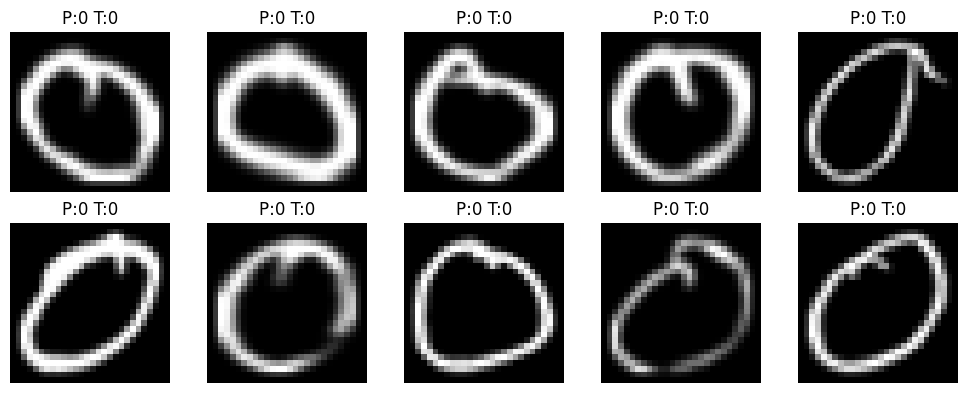

In [56]:
# Show prediction results
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("P:" + str(predicted_labels[i]) + " T:" + str(true_labels[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()